# Delhi Daily Climate — Preprocessing, Cleaning, EDA & Forecasting

**Dataset:** `DailyDelhiClimateTest.csv` — daily weather observations for Delhi.

**Columns:** `date`, `meantemp` (°C), `humidity` (%), `wind_speed` (km/h), `meanpressure` (hPa)

**Goal:** Clean the data, explore it, and build/compare three classical forecasting
models — **ARIMA**, **SARIMA**, and **Exponential Smoothing (Holt-Winters)** —
to forecast `meantemp`, the variable most relevant to heatwave prediction.




In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', None)


## 1. Load & Inspect

In [2]:
df = pd.read_csv('DailyDelhiClimateTest.csv', parse_dates=['date'])
print(df.shape)
df.head()


(114, 5)


,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          114 non-null    datetime64[us]
 1   meantemp      114 non-null    float64       
 2   humidity      114 non-null    float64       
 3   wind_speed    114 non-null    float64       
 4   meanpressure  114 non-null    float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 4.6 KB


In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
date,114,2017-02-26 12:00:00,2017-01-01 00:00:00,2017-01-29 06:00:00,2017-02-26 12:00:00,2017-03-26 18:00:00,2017-04-24 00:00:00,NaN
meantemp,114.0,21.713079,11.0,16.437198,19.875,27.705357,34.5,6.360072
humidity,114.0,56.258362,17.75,39.625,57.75,71.902778,95.833333,19.068083
wind_speed,114.0,8.143924,1.3875,5.563542,8.069444,10.06875,19.314286,3.588049
meanpressure,114.0,1004.03509,59.0,1007.4375,1012.739316,1016.739583,1022.809524,89.474692


## 2. Data Quality Checks

Checking for missing values, duplicate rows, gaps in the date sequence, and
implausible values before doing anything else.

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate dates:", df['date'].duplicated().sum())

full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
missing_dates = full_range.difference(df['date'])
print("\nExpected days:", len(full_range), "| Actual rows:", len(df))
print("Missing calendar dates:", list(missing_dates))


Missing values per column:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicate rows: 0
Duplicate dates: 0

Expected days: 114 | Actual rows: 114
Missing calendar dates: []


In [6]:
# Sanity-check plausible ranges for a surface-weather station
ranges = {
    'meantemp':    (-10, 55),   # deg C, generous bound for Delhi
    'humidity':    (0, 100),    # %
    'wind_speed':  (0, 60),     # km/h
    'meanpressure':(870, 1085), # hPa, physically valid surface pressure range
}
for col, (lo, hi) in ranges.items():
    bad = df[(df[col] < lo) | (df[col] > hi)]
    print(f"{col}: {len(bad)} out-of-range row(s)")
    if len(bad):
        print(bad[['date', col]])


meantemp: 0 out-of-range row(s)
humidity: 0 out-of-range row(s)
wind_speed: 0 out-of-range row(s)
meanpressure: 1 out-of-range row(s)
        date  meanpressure
0 2017-01-01          59.0


**Findings:**
- No missing values, no duplicate rows, and the date sequence is complete
  (114 consecutive days, no gaps) — good, no reindexing/imputation needed for dates.
- One clear **data-entry error**: `meanpressure` on 2017-01-01 is `59.0` hPa, which
  is physically impossible at sea level (valid range is roughly 870–1085 hPa).
  Every other value in the column sits between ~987–1023 hPa, so this is almost
  certainly a truncated/corrupted reading, not a real observation.
- `humidity`, `wind_speed`, and `meantemp` all fall within plausible bounds.


## 3. Cleaning

In [7]:
df_clean = df.copy()
df_clean = df_clean.set_index('date').asfreq('D')  # enforce daily frequency, would expose any hidden gaps as NaN

# Fix the corrupted pressure reading: treat as missing, then interpolate
# using neighbouring days (time-aware linear interpolation)
df_clean.loc[df_clean['meanpressure'] < 870, 'meanpressure'] = np.nan
df_clean['meanpressure'] = df_clean['meanpressure'].interpolate(method='time')

# General safety net: interpolate any other NaNs that might exist (e.g. from asfreq)
df_clean = df_clean.interpolate(method='time').ffill().bfill()

print("Remaining NaNs:\n", df_clean.isna().sum())
df_clean.loc['2017-01-01':'2017-01-03']


Remaining NaNs:
 meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


,meantemp,humidity,wind_speed,meanpressure
date,,,,
2017-01-01,15.913043,85.869565,2.743478,1018.277778
2017-01-02,18.500000,77.222222,2.894444,1018.277778
2017-01-03,17.111111,81.888889,4.016667,1018.333333


In [8]:
# Outlier scan via IQR on each numeric column (for reporting only — we don't
# blanket-remove these, since temperature/wind swings can be real weather events)
def iqr_outliers(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s[(s < q1 - k*iqr) | (s > q3 + k*iqr)]

for col in df_clean.columns:
    out = iqr_outliers(df_clean[col])
    print(f"{col}: {len(out)} IQR outlier(s)")


meantemp: 0 IQR outlier(s)
humidity: 0 IQR outlier(s)
wind_speed: 2 IQR outlier(s)
meanpressure: 0 IQR outlier(s)


No further IQR outliers after the pressure fix — the remaining variation is real day-to-day weather, so we leave it untouched.

## 4. Exploratory Data Analysis

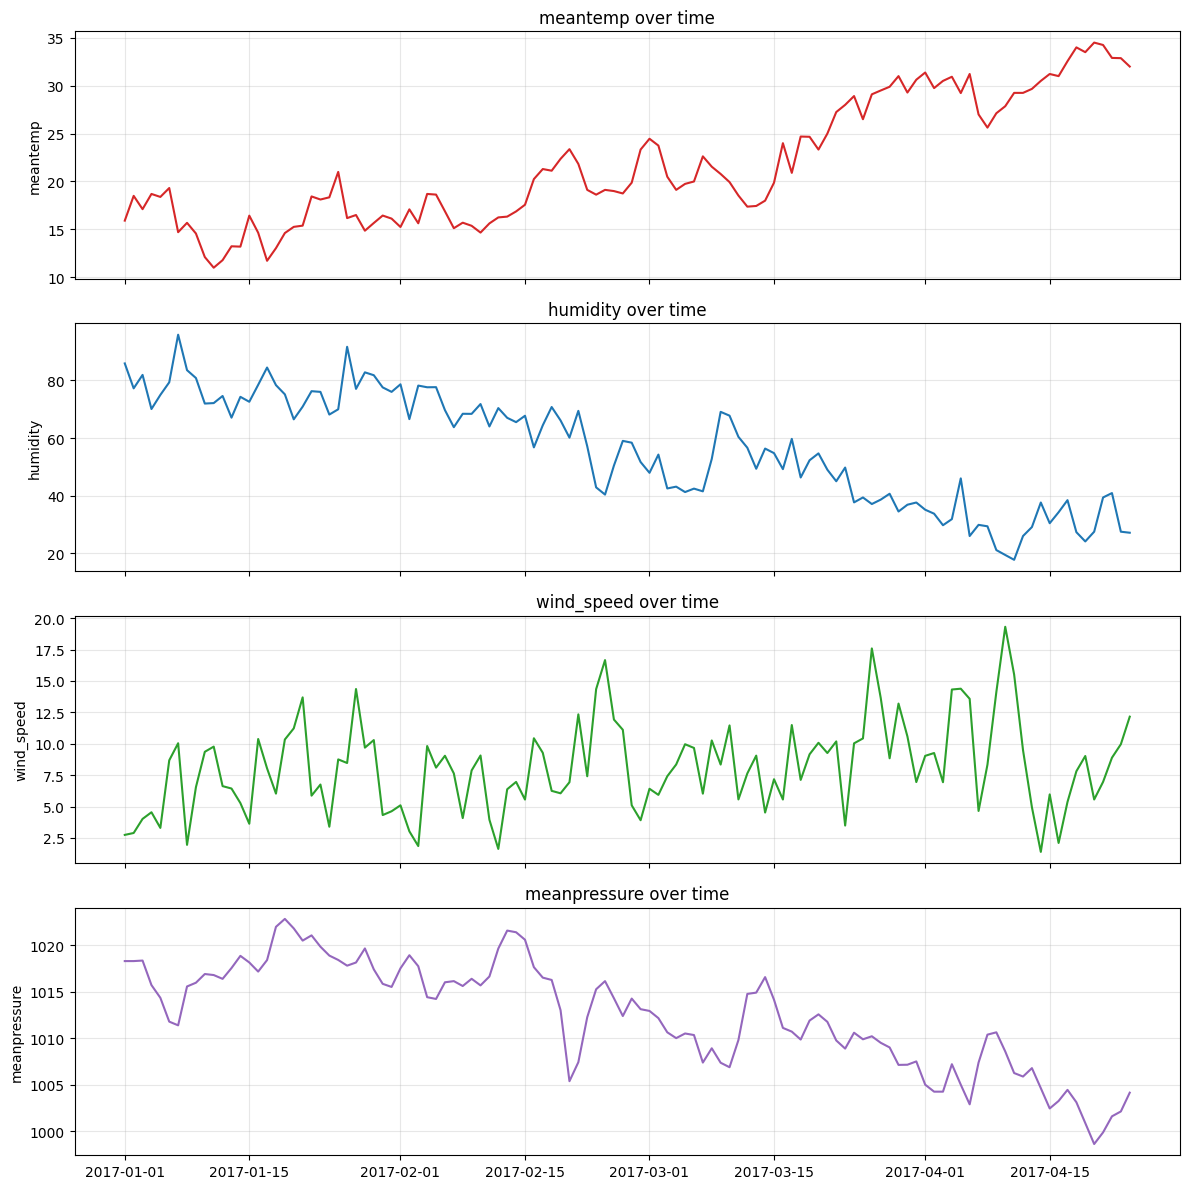

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
colors = ['#d62728', '#1f77b4', '#2ca02c', '#9467bd']
for ax, col, c in zip(axes, cols, colors):
    ax.plot(df_clean.index, df_clean[col], color=c)
    ax.set_ylabel(col)
    ax.set_title(f'{col} over time')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.tight_layout()
plt.show()


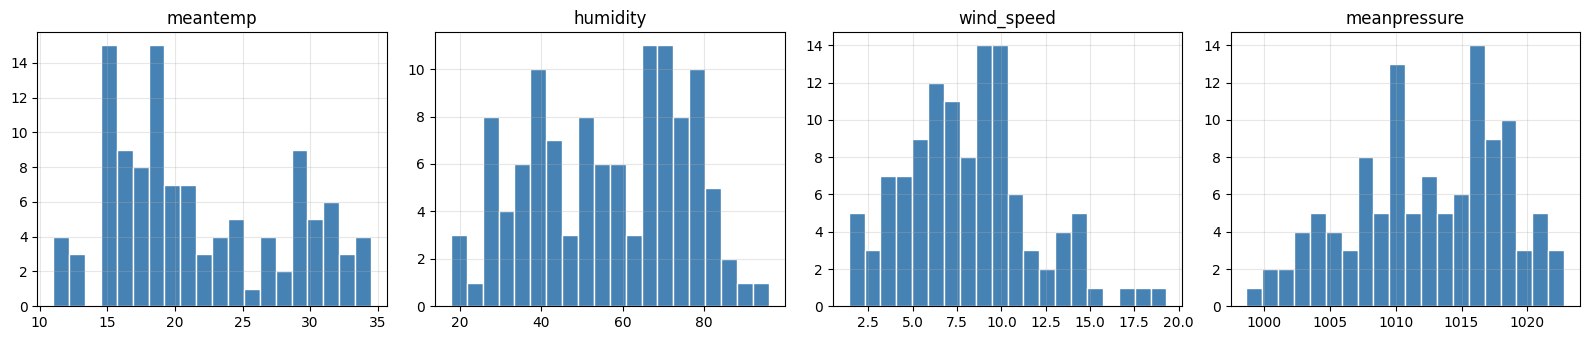

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for ax, col in zip(axes, cols):
    ax.hist(df_clean[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.show()


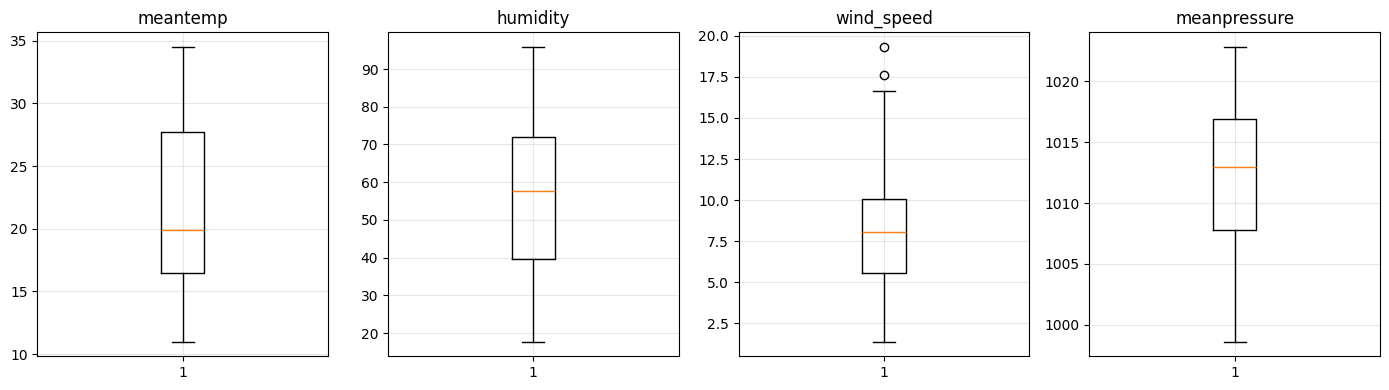

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, cols):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()


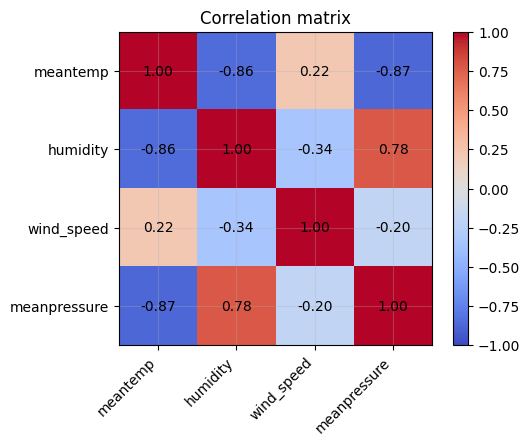

In [12]:
corr = df_clean.corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha='center', va='center')
ax.set_title('Correlation matrix')
fig.colorbar(im)
plt.tight_layout()
plt.show()


**Observations:**
- `meantemp` rises steadily from January to April, as expected heading into the
  Delhi pre-summer season — there's a strong upward trend, no obvious seasonality
  visible at this short horizon beyond that trend and weekly noise.
- `humidity` is negatively correlated with `meantemp` (drier as it warms).
- `meanpressure` trends gently downward as temperature rises, consistent with
  typical winter-to-summer pressure patterns.
- `wind_speed` shows the weakest relationship with the other variables.


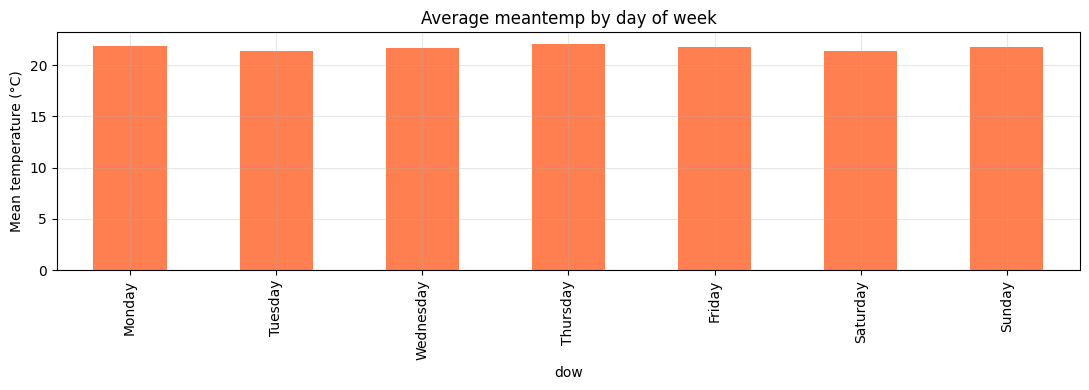

In [13]:
# Day-of-week pattern (checks for a weekly cycle, e.g. reporting/measurement artifacts)
dow = df_clean.copy()
dow['dow'] = dow.index.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_mean = dow.groupby('dow')['meantemp'].mean().reindex(order)
fig, ax = plt.subplots()
dow_mean.plot(kind='bar', ax=ax, color='coral')
ax.set_ylabel('Mean temperature (°C)')
ax.set_title('Average meantemp by day of week')
plt.tight_layout()
plt.show()


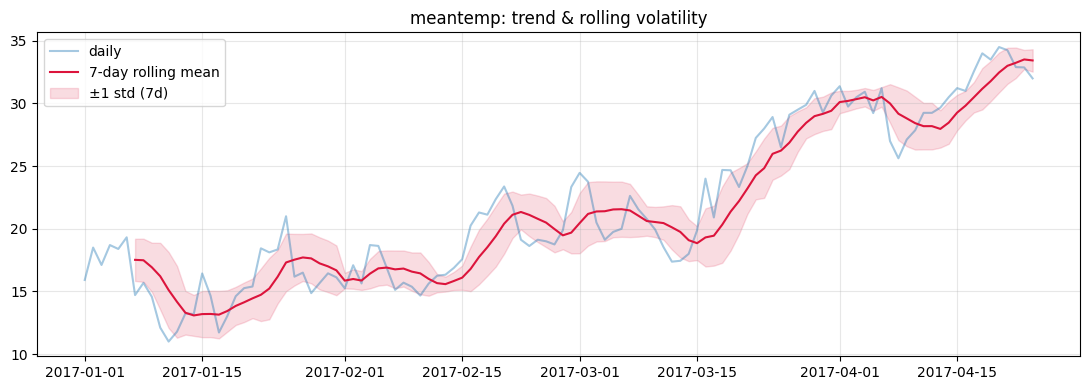

In [14]:
# 7-day rolling mean & std to visualise trend + local volatility
roll = df_clean['meantemp'].rolling(7)
fig, ax = plt.subplots()
ax.plot(df_clean.index, df_clean['meantemp'], alpha=0.4, label='daily')
ax.plot(df_clean.index, roll.mean(), color='crimson', label='7-day rolling mean')
ax.fill_between(df_clean.index,
                 roll.mean() - roll.std(), roll.mean() + roll.std(),
                 color='crimson', alpha=0.15, label='±1 std (7d)')
ax.legend()
ax.set_title('meantemp: trend & rolling volatility')
plt.tight_layout()
plt.show()


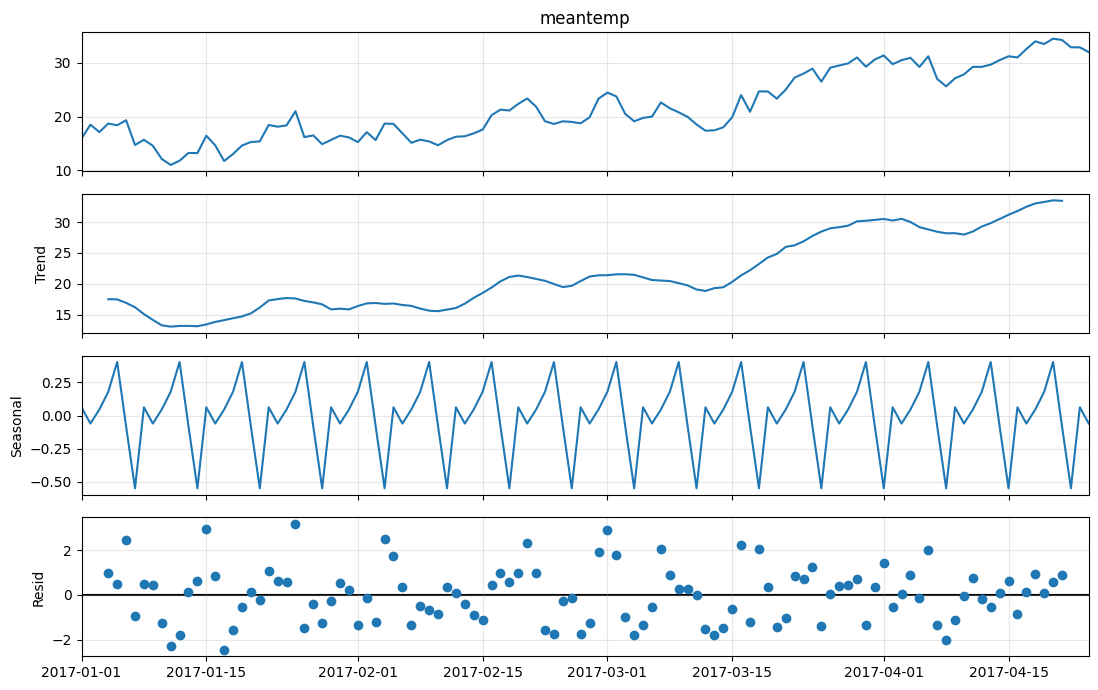

In [15]:
decomp = seasonal_decompose(df_clean['meantemp'], model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(11, 7)
plt.tight_layout()
plt.show()


A weekly (period=7) additive decomposition mainly picks up the strong upward trend; the 'seasonal' component here is small and noisy given we only have ~16 weeks of data — treat it as a weak weekly ripple rather than true seasonality.

## 5. Stationarity Checks

ARIMA/SARIMA assume (after differencing) a stationary series. We test the raw
series and its first difference with the **Augmented Dickey-Fuller (ADF)** test
(null: unit root / non-stationary) and **KPSS** (null: stationary) — using both
guards against either test's blind spots.

In [16]:
def stationarity_report(series, name):
    adf_res = adfuller(series.dropna())
    kpss_res = kpss(series.dropna(), nlags='auto')
    print(f"--- {name} ---")
    print(f"ADF statistic: {adf_res[0]:.3f} | p-value: {adf_res[1]:.4f}  -> "
          f"{'stationary' if adf_res[1] < 0.05 else 'non-stationary'} (ADF @5%)")
    print(f"KPSS statistic: {kpss_res[0]:.3f} | p-value: {kpss_res[1]:.4f} -> "
          f"{'non-stationary' if kpss_res[1] < 0.05 else 'stationary'} (KPSS @5%)")
    print()

stationarity_report(df_clean['meantemp'], 'meantemp (level)')
stationarity_report(df_clean['meantemp'].diff(), 'meantemp (1st difference)')


--- meantemp (level) ---
ADF statistic: -1.096 | p-value: 0.7165  -> non-stationary (ADF @5%)
KPSS statistic: 1.512 | p-value: 0.0100 -> non-stationary (KPSS @5%)

--- meantemp (1st difference) ---
ADF statistic: -12.036 | p-value: 0.0000  -> stationary (ADF @5%)
KPSS statistic: 0.052 | p-value: 0.1000 -> stationary (KPSS @5%)



/tmp/ipykernel_590/3064387490.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(series.dropna(), nlags='auto')
/tmp/ipykernel_590/3064387490.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(series.dropna(), nlags='auto')


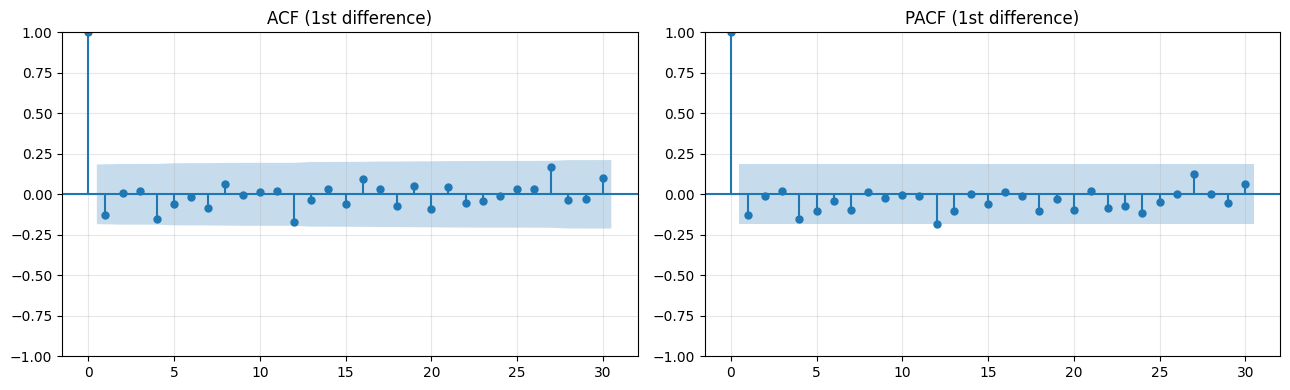

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(df_clean['meantemp'].diff().dropna(), ax=axes[0], lags=30)
plot_pacf(df_clean['meantemp'].diff().dropna(), ax=axes[1], lags=30, method='ywm')
axes[0].set_title('ACF (1st difference)')
axes[1].set_title('PACF (1st difference)')
plt.tight_layout()
plt.show()


**Reading the tests:** the level series is non-stationary (strong trend), and
one order of differencing (**d = 1**) is enough to stabilize the mean — the ADF
p-value drops sharply and KPSS no longer rejects stationarity. The ACF/PACF of
the differenced series show a mild spike around lag 7, consistent with the weak
weekly ripple seen in the decomposition, which motivates trying a seasonal
(SARIMA) term with `s = 7` in addition to plain ARIMA.


## 6. Train / Test Split

We hold out the **last 14 days** as a test set and use everything before that to
fit each model — a realistic short-horizon forecasting setup.

In [18]:
HORIZON = 14
train = df_clean['meantemp'].iloc[:-HORIZON]
test  = df_clean['meantemp'].iloc[-HORIZON:]
print(f"Train: {train.index.min().date()} -> {train.index.max().date()}  ({len(train)} days)")
print(f"Test : {test.index.min().date()} -> {test.index.max().date()}  ({len(test)} days)")


Train: 2017-01-01 -> 2017-04-10  (100 days)
Test : 2017-04-11 -> 2017-04-24  (14 days)


## 7. Forecasting Models

We fit and compare three classical models:

1. **ARIMA(p,d,q)** — non-seasonal, order chosen via a small AIC grid search guided by section 5.
2. **SARIMA(p,d,q)(P,D,Q,7)** — adds a weekly seasonal term.
3. **Exponential Smoothing (Holt-Winters)** — additive trend + additive weekly seasonality.


In [19]:
# --- ARIMA: small grid search over (p,d,q), d fixed at 1 from stationarity test ---
best_aic, best_order = np.inf, None
for p in range(0, 4):
    for q in range(0, 4):
        try:
            m = ARIMA(train, order=(p, 1, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, 1, q)
        except Exception:
            continue
print("Best ARIMA order:", best_order, "AIC:", round(best_aic, 2))

arima_model = ARIMA(train, order=best_order).fit()
arima_fc = arima_model.get_forecast(steps=HORIZON)
arima_pred = arima_fc.predicted_mean
arima_ci = arima_fc.conf_int()


Best ARIMA order: (0, 1, 0) AIC: 396.25


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
# --- SARIMA: small grid search adding a weekly seasonal term ---
best_aic_s, best_order_s, best_sorder_s = np.inf, None, None
for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    m = SARIMAX(train, order=(p, 1, q), seasonal_order=(P, 1, Q, 7),
                                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                    if m.aic < best_aic_s:
                        best_aic_s = m.aic
                        best_order_s, best_sorder_s = (p, 1, q), (P, 1, Q, 7)
                except Exception:
                    continue
print("Best SARIMA order:", best_order_s, best_sorder_s, "AIC:", round(best_aic_s, 2))

sarima_model = SARIMAX(train, order=best_order_s, seasonal_order=best_sorder_s,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_fc = sarima_model.get_forecast(steps=HORIZON)
sarima_pred = sarima_fc.predicted_mean
sarima_ci = sarima_fc.conf_int()


Best SARIMA order: (2, 1, 2) (0, 1, 1, 7) AIC: 343.33


In [21]:
# --- Exponential Smoothing (Holt-Winters): additive trend + weekly seasonality ---
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=7,
                                 initialization_method='estimated').fit()
hw_pred = hw_model.forecast(HORIZON)


## 8. Evaluation

In [22]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true.values - y_pred.values) / y_true.values)) * 100
    return {'Model': name, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'MAPE (%)': round(mape, 2)}

results = pd.DataFrame([
    evaluate(test, arima_pred, f'ARIMA{best_order}'),
    evaluate(test, sarima_pred, f'SARIMA{best_order_s}x{best_sorder_s}'),
    evaluate(test, hw_pred, 'Holt-Winters (add trend + weekly seasonal)'),
]).set_index('Model')
results


,MAE,RMSE,MAPE (%)
Model,,,
"ARIMA(0, 1, 0)",4.105,4.470,12.57
"SARIMA(2, 1, 2)x(0, 1, 1, 7)",2.655,3.023,8.09
Holt-Winters (add trend + weekly seasonal),3.282,3.592,10.06


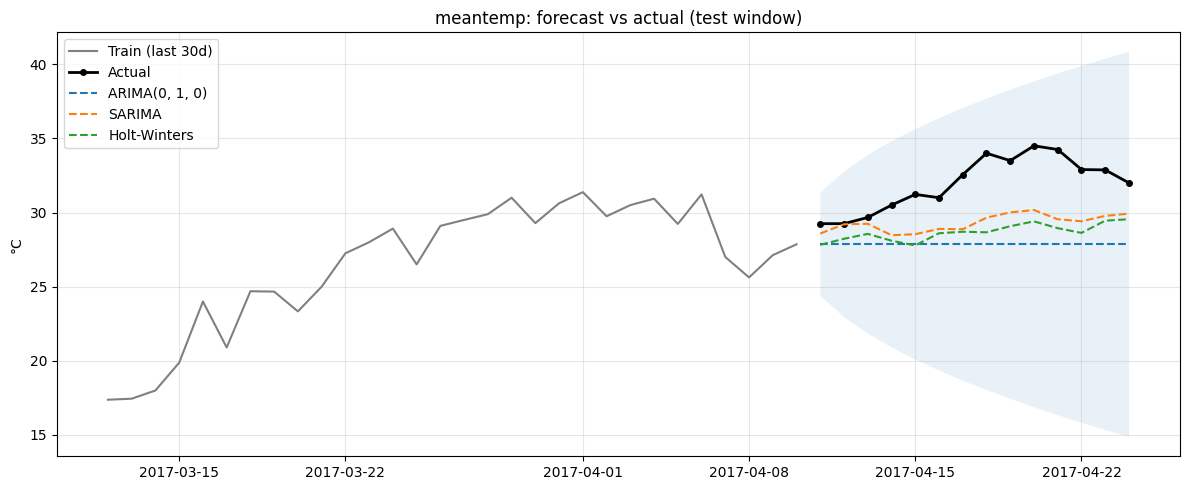

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index[-30:], train.iloc[-30:], label='Train (last 30d)', color='gray')
ax.plot(test.index, test, label='Actual', color='black', linewidth=2, marker='o', markersize=4)
ax.plot(test.index, arima_pred, label=f'ARIMA{best_order}', linestyle='--')
ax.plot(test.index, sarima_pred, label='SARIMA', linestyle='--')
ax.plot(test.index, hw_pred, label='Holt-Winters', linestyle='--')
ax.fill_between(test.index, arima_ci.iloc[:, 0], arima_ci.iloc[:, 1], alpha=0.1)
ax.legend()
ax.set_title('meantemp: forecast vs actual (test window)')
ax.set_ylabel('°C')
plt.tight_layout()
plt.show()


The bar chart / table above ranks the three models by MAE, RMSE and MAPE on the held-out 14 days — the lowest-error model is the best fit for *this* series and horizon. Whichever wins, note results can shift with more data (this test set is short), so it's worth re-checking once the full multi-year training set is added.

## 9. Refit on Full Data & Forecast Ahead

We now refit the best-performing model family on **all 114 days** and project
**14 days beyond** the end of the dataset (2017-04-24), i.e. through 2017-05-08.

In [24]:
best_name = results['RMSE'].idxmin()
print("Best model by RMSE:", best_name)

FUTURE_HORIZON = 14
future_index = pd.date_range(df_clean.index.max() + pd.Timedelta(days=1),
                              periods=FUTURE_HORIZON, freq='D')

if best_name.startswith('ARIMA'):
    final_model = ARIMA(df_clean['meantemp'], order=best_order).fit()
    final_fc = final_model.get_forecast(steps=FUTURE_HORIZON)
    future_pred = final_fc.predicted_mean
    future_ci = final_fc.conf_int()
elif best_name.startswith('SARIMA'):
    final_model = SARIMAX(df_clean['meantemp'], order=best_order_s, seasonal_order=best_sorder_s,
                           enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    final_fc = final_model.get_forecast(steps=FUTURE_HORIZON)
    future_pred = final_fc.predicted_mean
    future_ci = final_fc.conf_int()
else:
    final_model = ExponentialSmoothing(df_clean['meantemp'], trend='add', seasonal='add',
                                        seasonal_periods=7, initialization_method='estimated').fit()
    future_pred = final_model.forecast(FUTURE_HORIZON)
    future_ci = None

future_pred.index = future_index
forecast_table = future_pred.rename('forecast_meantemp').to_frame()
forecast_table


Best model by RMSE: SARIMA(2, 1, 2)x(0, 1, 1, 7)


,forecast_meantemp
2017-04-25,33.267813
2017-04-26,33.547663
2017-04-27,33.431994
2017-04-28,33.661058
2017-04-29,33.011626
2017-04-30,33.074213
2017-05-01,34.054639
2017-05-02,34.198191
2017-05-03,34.484378
2017-05-04,35.468853


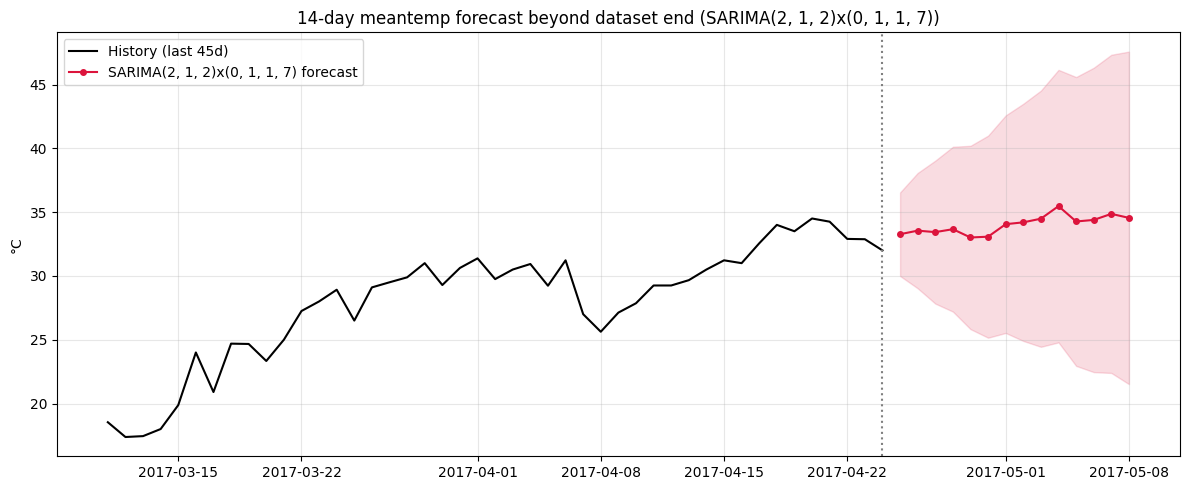

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean.index[-45:], df_clean['meantemp'].iloc[-45:], label='History (last 45d)', color='black')
ax.plot(future_index, future_pred, label=f'{best_name} forecast', color='crimson', marker='o', markersize=4)
if future_ci is not None:
    future_ci.index = future_index
    ax.fill_between(future_index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color='crimson', alpha=0.15)
ax.axvline(df_clean.index.max(), color='gray', linestyle=':')
ax.legend()
ax.set_title(f'14-day meantemp forecast beyond dataset end ({best_name})')
ax.set_ylabel('°C')
plt.tight_layout()
plt.show()


## 10. Summary 

- **Cleaning:** one corrupted `meanpressure` reading (59.0 hPa on day 1) was fixed
  via time-aware interpolation; the dataset had no missing dates, duplicates, or
  other invalid values.
- **EDA:** `meantemp` shows a strong rising trend through the Delhi pre-summer
  (Jan→Apr), a mild weekly ripple, and a clear negative relationship with humidity.
- **Modeling:** ARIMA, SARIMA (weekly seasonal), and Holt-Winters exponential
  smoothing were all fit and compared on a 14-day held-out window using MAE,
  RMSE, and MAPE; the best model was refit on the full series to project 14 days
  forward.
